In [100]:
import numpy as np
import matplotlib.pyplot as plt

from resource_model import ResourceModel
from const import (IAI_TO_IMAGE_CLASSES, REGION_TO_CLASS_DICT)

In [101]:
# Aluminium regions

aluminium_regions = {
    'Africa' : ['Africa'], 
    'Asia (ex China)' : ['Asia (ex China)'], 
    'China (Estimated)' : ['China (Estimated)'],
    'Estimated Unreported to IAI' : ['Estimated Unreported to IAI'], 
    'Gulf Cooperation Council' : ['Gulf Cooperation Council'],
    'North America' : ['North America'], 
    'Oceania' : ['Oceania'], 
    'Russia & Eastern Europe' : ['Russia & Eastern Europe'],
    'South America' : ['South America'],
    'Western & Central Europe' : ['Western & Central Europe']
}

aluminium_regions = {
    'all together' : list(aluminium_regions.keys()),
}


In [102]:
# Aluminium
aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                       image_mat_available = True, start_year = 1998, end_year = 2024)

aluminium.data_grouped_regions(regions_grouping = aluminium_regions) 

<Axes: >

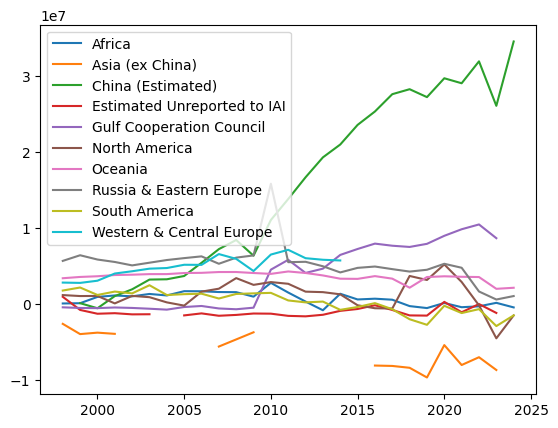

In [103]:
aluminium.sum_IMAGE_drivers_regions(IAI_TO_IMAGE_CLASSES)
aluminium.match_MAT_data_to_regions_year(match_external_regions=True)
aluminium.calculate_historic_other_fraction()
aluminium.historic_other_fraction_consumption.plot()

In [104]:
aluminium.historic_other_fraction_consumption

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


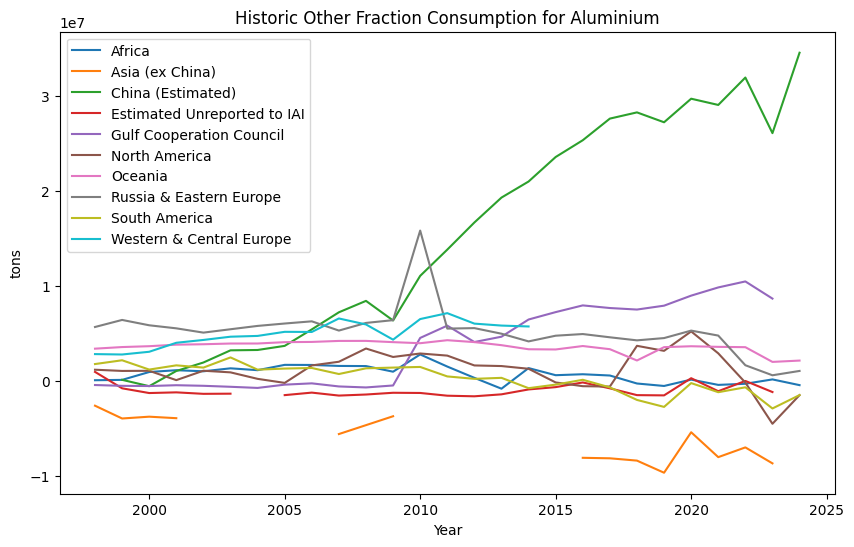

In [105]:
# Plot historic aother fraction app consumption

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aluminium.historic_other_fraction_consumption, 
        label = aluminium.historic_other_fraction_consumption.columns)
ax.set_title('Historic Other Fraction Consumption for Aluminium')
plt.xlabel('Year')
plt.ylabel('tons')

plt.legend()

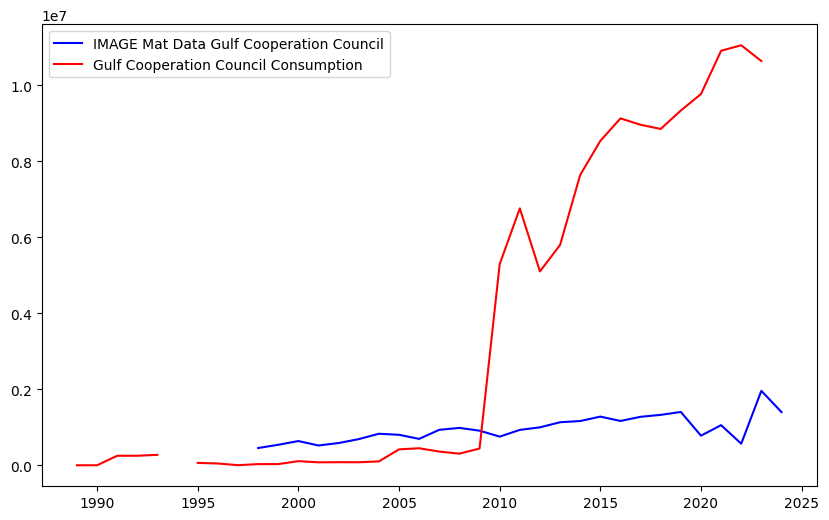

In [106]:
# Plot IMAGE Mat data and apparent cons data for region x

#
region_name = 'Gulf Cooperation Council'

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aluminium.image_mat_material_regions.loc[:, region_name], 
                                                 label= f'IMAGE Mat Data {region_name}', color='blue')

ax.plot(aluminium.historic_consumption_data.loc[:, region_name], 
        label = f'{region_name} Consumption', color='red')

plt.legend()


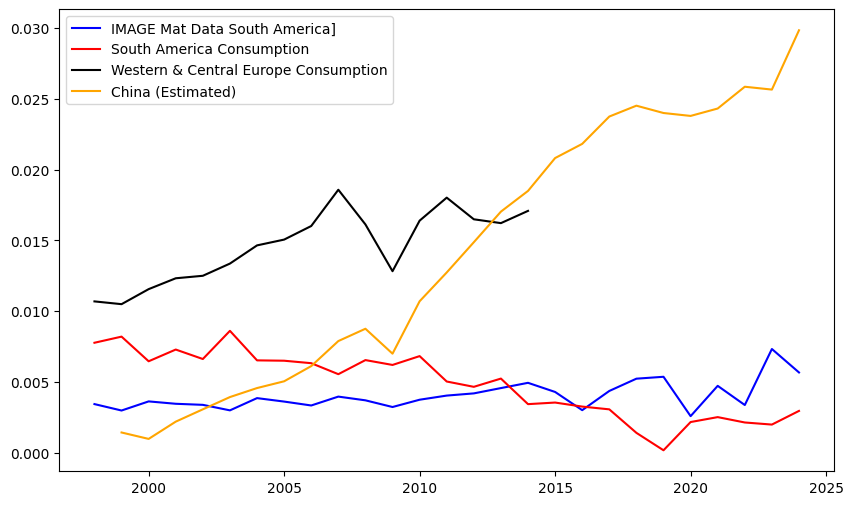

In [107]:
# Plot IMAGE Mat data and apparent cons per capita data for region x

#
region_name = 'South America'

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aluminium.image_mat_material_regions.loc[:, region_name] / aluminium.pop_100.loc[1998:2024, region_name], 
                                                 label= f'IMAGE Mat Data {region_name}]', color='blue')

ax.plot(aluminium.historic_consumption_data.loc[:, region_name] / aluminium.pop_100.loc[1998:2024, region_name], 
        label = f'{region_name} Consumption', color='red')

ax.plot(aluminium.historic_consumption_data.loc[:, 'Western & Central Europe'] / aluminium.pop_100.loc[1998:2024, 'Western & Central Europe'], 
        label = 'Western & Central Europe Consumption', color='black')

ax.plot(aluminium.historic_consumption_data.loc[:, 'China (Estimated)'] / aluminium.pop_100.loc[1998:2024, 'China (Estimated)'], 
        label = 'China (Estimated)', color='orange')

# ax.plot(aluminium.historic_consumption_data.loc[:, 'Africa'] / aluminium.pop_100.loc[1998:2024, 'Africa'], 
#         label = 'Africa', color='green')

# ax.plot(aluminium.image_mat_material_regions.loc[:, 'Africa'] / aluminium.pop_100.loc[1998:2024, 'Africa'], 
#                                                  label='IMAGE Mat Data Africa', color='turquoise')

plt.legend()


In [108]:
# Deal with negative values in other fraction BEFORE recalculation of other fraction consumption

# 1) Africa: all negative: assumption that apparent MAT is 60% of total consumption (mean until 2017)
# Share of IAMGE MAT data to total consumption
share = (aluminium.image_mat_material_regions.loc[:2017]/aluminium.historic_consumption_data.loc[:2017]*100).mean()
share['Africa']

# starting at 2013 (when negative values start):
aluminium.image_mat_material_regions.loc[:, 'Africa'] = aluminium.historic_consumption_data.loc[:, 'Africa'] * share['Africa'] / 100

# 4) North America
# problem starts at 2015, so take share mean of IMAGE Mat data before that and apply it to 2015-2024
share_na = (aluminium.image_mat_material_regions.loc[:2015]/aluminium.historic_consumption_data.loc[:2015]*100).mean()
aluminium.image_mat_material_regions.loc[:, 'North America'] = aluminium.historic_consumption_data.loc[:, 'North America'] * share_na['North America'] / 100

# 6) South America: assume that IMAGE mat is correct and that share of Mat until 2010 is correct and that app cons needs to be adjusted accordingly 
share_sa = (aluminium.image_mat_material_regions.loc[:2010, 'South America'] / aluminium.historic_consumption_data.loc[:2010, 'South America']).mean()
aluminium.historic_consumption_data.loc[:, 'South America'] = aluminium.image_mat_material_regions.loc[:, 'South America'] / share_sa

# Deal with negative values in other fraction AFTER recalculation of other fraction consumption
# redo calculation of historic other fraction consumption 
aluminium.calculate_historic_other_fraction()

# 2) rest of Asia: assume that IMAGE Mat is correct and is total. per cap consumption 
# so will be projected on total not on diff
aluminium.historic_other_fraction_consumption.loc[:, 'Asia (ex China)'] = aluminium.historic_consumption_data.loc[:, 'Asia (ex China)']


# 3) Estimated Unreported to IAI: assume that IMAGE Mat is correct (these are mostlly IMAGE region 6 regions)
# Most are small island territories, overseas territories or constituent countries mainly linked to France
aluminium.historic_other_fraction_consumption.loc[:, 'Estimated Unreported to IAI'] = aluminium.historic_consumption_data.loc[:, 'Estimated Unreported to IAI']

# 5) Gulf Cooperation Council: remove negative values to nan, no problems in more recent years
aluminium.historic_other_fraction_consumption.loc[aluminium.historic_other_fraction_consumption.loc[:, 'Gulf Cooperation Council'] < 0, 'Gulf Cooperation Council'] = np.nan

# Finally check the whole dataframe for single negative values and make them NaN
aluminium.historic_other_fraction_consumption[aluminium.historic_other_fraction_consumption < 0] = np.nan

In [109]:
aluminium.historic_other_fraction_consumption

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1988,NaN,6.264801e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,5.223609e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,NaN,3.435971e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991,NaN,6.191659e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992,NaN,7.972590e+05,NaN,4.689961e+06,NaN,NaN,NaN,NaN,NaN,NaN
1993,NaN,5.913259e+05,NaN,4.738436e+06,NaN,NaN,NaN,NaN,NaN,NaN
1994,NaN,6.325063e+05,NaN,3.989005e+06,NaN,NaN,NaN,NaN,NaN,NaN
1995,NaN,2.960242e+05,NaN,2.362097e+06,NaN,NaN,NaN,NaN,NaN,NaN
1996,NaN,3.865528e+05,NaN,2.216125e+06,NaN,NaN,NaN,NaN,NaN,NaN
1997,NaN,4.942532e+05,NaN,1.749081e+06,NaN,NaN,NaN,NaN,NaN,NaN


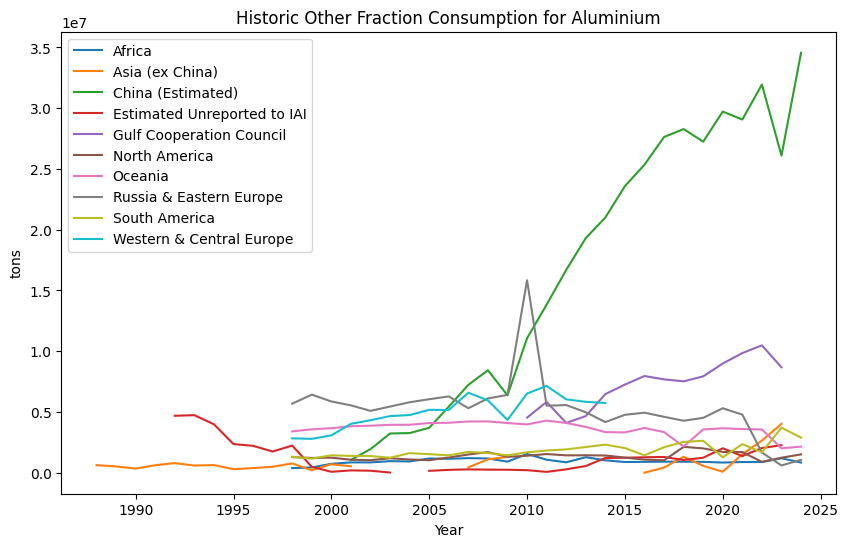

In [110]:
# Plot historic aother fraction app consumption

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aluminium.historic_other_fraction_consumption, 
        label = aluminium.historic_other_fraction_consumption.columns)
ax.set_title('Historic Other Fraction Consumption for Aluminium')
plt.xlabel('Year')
plt.ylabel('tons')

plt.legend()

In [111]:
# Fit models
aluminium.calculate_regressors(aluminium.historic_other_fraction_consumption)
aluminium.fit_models()
# Best models
aluminium.best_rmse_models
aluminium.merged_rmse_r2

Optimal parameters not found: Number of calls to function has reached maxfev = 800.


all together          
                                 RMSE       R^2
Model                                          
log-log model                0.001720  0.398208
semi-log model               0.001401  0.216719
log-inverse model            0.001862  0.342485
log-log-inverse model        0.001723  0.398341
log-log-square model         0.001749  0.408670
non-linear inverse model     0.001354       NaN
gompertz model               0.001320       NaN
logistic growth model             NaN       NaN
limited growth model         0.001365       NaN

<Axes: >

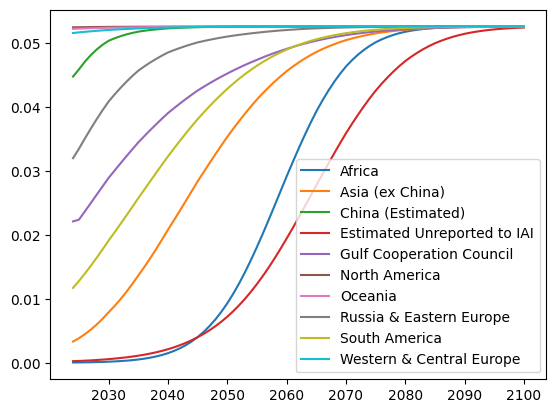

In [112]:
aluminium.project_on_total(list(IAI_TO_IMAGE_CLASSES.keys()), 
                        REGION_TO_CLASS_DICT,
                        aluminium.gdp_pc_100)

aluminium.projection_per_region.plot()